# Player Experience Modeling — Predictive Modeling Exercise (Student Version)

This notebook follows the lecture cadence for **Aula 4**.

## Goal
Build a predictive model that estimates the **hidden skill tier** of each player:
- Bronze
- Silver
- Gold
- Diamond

## Files
- `students_dataset.csv` → observable telemetry
- `ground_truth_hidden.csv` → hidden labels used **only later** for evaluation

## Today’s workflow
1. Load and inspect the dataset
2. Revisit descriptive vs predictive modeling
3. Identify useful telemetry variables
4. Engineer role-aware features
5. Build a normalized baseline model
6. Split data into train / test
7. Train a Random Forest model
8. Evaluate with accuracy, precision, recall, F1, and confusion matrix
9. Inspect feature importance
10. Optionally perform a small ablation study


In [312]:
# Libraries used in this notebook
# pandas / numpy: data handling
# matplotlib: plotting
# sklearn: machine learning, preprocessing and evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance


## The Prediction Problem

We do **not** observe skill directly.

We observe **player telemetry** and use it to estimate a hidden variable:

**Input:** player telemetry  
**Output:** predicted skill tier

This is a **supervised classification** problem.


In [313]:
# Load the observable telemetry dataset
df = pd.read_csv("ctf-simulator/students_dataset.csv")
df.head()


,PlayerName,PlayerID,PreferredRole,Matches,Wins,Losses,Draws,WinRate,Kills,Deaths,...,DefenseStopsNearFlag,ReturnsUnderPressure,TimeNearCarrierPerMatch,KillsWhileCarrierAlivePerMatch,DefenseStopsNearFlagPerMatch,ReturnsUnderPressurePerMatch,FlagRoomPresenceUnderThreat,FlagRoomPresenceUnderThreatPerMatch,KillsNearCarrier,KillsNearCarrierPerMatch
0,P29,29,runner,80,62,15,3,0.775000,2113,1803,...,0,19,4.300000,6.575000,0.0,0.237500,5217,65.212500,21,0.262500
1,P57,57,runner,82,63,14,5,0.768293,2012,1869,...,0,20,4.280488,5.939024,0.0,0.243902,5746,70.073171,20,0.243902
2,P73,73,runner,80,60,14,6,0.750000,2197,2019,...,0,13,3.987500,5.787500,0.0,0.162500,2617,32.712500,22,0.275000
3,P13,13,runner,81,58,21,2,0.716049,2207,2037,...,0,22,6.185185,6.814815,0.0,0.271605,1869,23.074074,36,0.444444
4,P5,5,runner,81,57,20,4,0.703704,2109,1941,...,0,20,7.209877,6.308642,0.0,0.246914,3161,39.024691,33,0.407407


## 1. Quick recap — descriptive vs predictive

### Descriptive modeling
Helps us understand patterns in the data.

Example questions:
- What happened?
- Which roles behave differently?
- Which metrics are correlated?

### Predictive modeling
Uses observed data to estimate an unknown target.

Example questions:
- What tier is this player likely to be?
- Can we estimate hidden skill from telemetry?


## 2. Inspect the dataset

### Tasks
- inspect shape
- inspect columns
- inspect descriptive statistics

### Reminder
Before modeling, we need to understand:
- what features exist
- what they measure
- what their scales look like


In [314]:
print("Shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print("-", c)

df.describe()


Shape: (100, 39)

Columns:
- PlayerName
- PlayerID
- PreferredRole
- Matches
- Wins
- Losses
- Draws
- WinRate
- Kills
- Deaths
- KDR
- KillsPerMatch
- DeathsPerMatch
- DuelsWon
- DuelsLost
- FlagGrabs
- Captures
- Returns
- Interceptions
- DefenseStops
- Overextensions
- ObjectiveActions
- GrabsPerMatch
- CapturesPerMatch
- ReturnsPerMatch
- InterceptionsPerMatch
- ObjectiveActionsPerMatch
- TimeNearCarrier
- KillsWhileCarrierAlive
- DefenseStopsNearFlag
- ReturnsUnderPressure
- TimeNearCarrierPerMatch
- KillsWhileCarrierAlivePerMatch
- DefenseStopsNearFlagPerMatch
- ReturnsUnderPressurePerMatch
- FlagRoomPresenceUnderThreat
- FlagRoomPresenceUnderThreatPerMatch
- KillsNearCarrier
- KillsNearCarrierPerMatch


,PlayerID,Matches,Wins,Losses,Draws,WinRate,Kills,Deaths,KDR,KillsPerMatch,...,DefenseStopsNearFlag,ReturnsUnderPressure,TimeNearCarrierPerMatch,KillsWhileCarrierAlivePerMatch,DefenseStopsNearFlagPerMatch,ReturnsUnderPressurePerMatch,FlagRoomPresenceUnderThreat,FlagRoomPresenceUnderThreatPerMatch,KillsNearCarrier,KillsNearCarrierPerMatch
count,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,50.500000,80.000000,33.48000,33.480000,13.040000,0.418097,1261.100000,1261.10000,1.034292,15.738879,...,111.220000,8.450000,11.337843,2.455622,1.392939,0.105304,2654.070000,33.132756,42.61000,0.533109
std,29.011492,1.874874,9.92546,7.147056,5.120606,0.121126,548.097379,574.49944,0.185922,6.761063,...,195.522795,6.440677,7.438526,2.002052,2.450693,0.079669,1677.978668,20.979378,40.04742,0.500213
min,1.000000,74.000000,17.00000,14.000000,2.000000,0.212500,389.000000,377.00000,0.581808,4.743902,...,0.000000,0.000000,3.592593,0.283951,0.000000,0.000000,849.000000,10.884615,4.00000,0.049383
25%,25.750000,79.000000,27.75000,29.750000,9.000000,0.349038,802.500000,815.75000,0.898353,10.167917,...,0.000000,3.000000,6.163580,0.820673,0.000000,0.039221,1205.000000,15.263889,17.00000,0.215931
50%,50.500000,80.000000,31.00000,34.000000,13.000000,0.387500,1266.000000,1306.50000,1.016897,15.760632,...,0.000000,7.000000,8.298071,1.910737,0.000000,0.085893,1915.500000,23.500452,24.00000,0.301899
75%,75.250000,81.000000,36.00000,38.000000,16.250000,0.450305,1687.500000,1761.25000,1.145881,20.957628,...,85.750000,12.000000,16.257904,3.444444,1.071875,0.148611,4081.250000,50.487805,59.25000,0.721310
max,100.000000,84.000000,63.00000,51.000000,28.000000,0.775000,2343.000000,2312.00000,1.548193,28.228916,...,538.000000,32.000000,35.365854,7.710843,6.635135,0.385542,6739.000000,91.067568,145.00000,1.812500


## 3. Short descriptive check

This is still **descriptive**, not predictive.

We are only summarizing patterns by role.


In [315]:
# GROUPBY EXAMPLE
# Input: dataframe with telemetry
# Output: average values by PreferredRole
# Goal: show that grouped summaries describe behavior, but do not predict hidden skill

df.groupby("PreferredRole")[[
    "CapturesPerMatch",
    "TimeNearCarrierPerMatch",
    "DefenseStopsNearFlagPerMatch"
]].mean()


,CapturesPerMatch,TimeNearCarrierPerMatch,DefenseStopsNearFlagPerMatch
PreferredRole,,,
defender,0.008905,9.670308,5.571755
midfield,0.034618,7.876456,0.000000
runner,4.196613,4.869237,0.000000
support,0.075592,22.935371,0.000000


## 4. Identify useful variables

### Think before coding
Which variables seem relevant for:
- runner
- support
- defender
- risky / weak play

Write a few notes below before continuing.


**Your notes here**

- Runner:
- Support:
- Defender:
- Risk / weak play:


## 5. Feature engineering

We will combine raw telemetry into more meaningful concepts.

Target derived features:
- `ObjectiveImpact`
- `SupportImpact`
- `DefenseImpact`
- `RiskScore`

For the baseline model, these should later be **normalized** before weighting them.


In [316]:
# Input: dataframe with raw telemetry
# Output: same dataframe with engineered columns added
# Task: combine existing columns into higher-level features
def build_engineered_features(df):
    df = df.copy()

    scaler = MinMaxScaler()

    # TODO: objective-oriented contribution
    # Suggested ingredients:
    # - CapturesPerMatch
    # - ReturnsPerMatch
    # - InterceptionsPerMatch
    # - ObjectiveActionsPerMatch
    objective_actions = [
        "CapturesPerMatch",
        "ReturnsPerMatch",
        "InterceptionsPerMatch",
        "ObjectiveActionsPerMatch"
    ]
    df["ObjectiveImpact"] = df[objective_actions].sum(axis=1)
    df["ObjectiveImpact"] = scaler.fit_transform(df[["ObjectiveImpact"]])

    # TODO: support-oriented contribution
    # Suggested ingredients:
    # - TimeNearCarrierPerMatch
    # - KillsNearCarrierPerMatch
    # - KillsWhileCarrierAlivePerMatch
    support_actions = [
        "TimeNearCarrierPerMatch",
        "KillsNearCarrierPerMatch",
        "KillsWhileCarrierAlivePerMatch"
    ]
    df["SupportImpact"] = df[support_actions].sum(axis=1)
    df["SupportImpact"] = scaler.fit_transform(df[["SupportImpact"]])

    # TODO: defense-oriented contribution
    # Suggested ingredients:
    # - DefenseStopsNearFlagPerMatch
    # - FlagRoomPresenceUnderThreatPerMatch
    # - ReturnsUnderPressurePerMatch
    defense_actions = [
        "DefenseStopsNearFlagPerMatch",
        "FlagRoomPresenceUnderThreatPerMatch",
        "ReturnsUnderPressurePerMatch"
    ]
    df["DefenseImpact"] = df[defense_actions].sum(axis=1)
    df["DefenseImpact"] = scaler.fit_transform(df[["DefenseImpact"]])

    # TODO: risk / discipline
    # Suggested idea:
    # - Overextensions / Matches
    df["RiskScore"] = df["Overextensions"] / df["Matches"]
    df["RiskScore"] = scaler.fit_transform(df[["RiskScore"]])

    return df

# TODO: call the function and preview the engineered columns
df = build_engineered_features(df)
df[[
    "PlayerName",
    "ObjectiveImpact",
    "SupportImpact",
    "DefenseImpact",
    "RiskScore"
]].head().round(3)

,PlayerName,ObjectiveImpact,SupportImpact,DefenseImpact,RiskScore
0,P29,0.976,0.140,0.628,0.647
1,P57,0.954,0.120,0.684,0.639
2,P73,0.928,0.108,0.253,0.000
3,P13,0.975,0.209,0.144,0.000
4,P5,0.833,0.224,0.327,0.000


## 6. Build a baseline model

A baseline is a **simple interpretable model**.

It gives us:
- a reference point
- a sanity check
- something to compare the ML model against

### Important
Because these variables live on different scales, normalize them before computing the weighted score.


In [317]:
# FUNCTION SKELETON
# Input:
#   df -> dataframe with engineered features
# Output:
#   dataframe with normalized features and baseline columns
#
# Task:
# 1. normalize the baseline feature columns
# 2. compute BaselineScore
# 3. rank by percentile
# 4. convert percentile into Bronze / Silver / Gold / Diamond

def percentile_to_tier(p):
    # TODO: implement the percentile → tier conversion
    # <= 0.40 -> Bronze
    # <= 0.75 -> Silver
    # <= 0.95 -> Gold
    # else      Diamond
    if p <= 0.40:
        return "Bronze"
    elif p <= 0.75:
        return "Silver"
    elif p <= 0.95:
        return "Gold"
    else:
        return "Diamond"

def add_baseline_model(df):
    df = df.copy()

    baseline_features = [
        "ObjectiveImpact",
        "SupportImpact",
        "DefenseImpact",
        "WinRate",
        "KDR",
        "RiskScore",
    ]

    # TODO: normalize these features (for example with MinMaxScaler)
    scaler = MinMaxScaler()
    df[baseline_features] = scaler.fit_transform(df[baseline_features])

    # TODO: create BaselineScore using the lecture weights
    # BaselineScore =
    # 0.30 * ObjectiveImpact
    # + 0.20 * SupportImpact
    # + 0.20 * DefenseImpact
    # + 0.15 * WinRate
    # + 0.10 * KDR
    # - 0.05 * RiskScore
    df["BaselineScore"] = (
        0.30 * df["ObjectiveImpact"]
        + 0.20 * df["SupportImpact"]
        + 0.20 * df["DefenseImpact"]
        + 0.15 * df["WinRate"]
        + 0.10 * df["KDR"]
        - 0.05 * df["RiskScore"]
    )

    # TODO: convert score to percentile rank
    df["Percentile"] = df["BaselineScore"].rank(pct=True)

    # TODO: convert percentile to tier
    df["BaselineTier"] = df["Percentile"].apply(percentile_to_tier)

    return df

# TODO: call the function and inspect a few rows
df = add_baseline_model(df)
df[["PlayerID", "BaselineScore", "Percentile", "BaselineTier"]].head(20)

,PlayerID,BaselineScore,Percentile,BaselineTier
0,29,0.625123,1.00,Diamond
1,57,0.614698,0.99,Diamond
2,73,0.546390,0.96,Diamond
3,13,0.549177,0.97,Diamond
4,5,0.543080,0.95,Gold
5,97,0.588962,0.98,Diamond
6,85,0.449405,0.87,Gold
7,45,0.493910,0.94,Gold
8,21,0.475920,0.92,Gold
9,25,0.478763,0.93,Gold


## 7. Reveal hidden labels for evaluation

Now we load the hidden truth file and merge it with the student dataset.

From here on, we can evaluate:
- the baseline
- machine learning models


In [318]:
truth = pd.read_csv("ctf-simulator/ground_truth_hidden.csv")
# TODO: merge on PlayerID so that the dataframe contains the hidden TrueTier column
df = df.merge(truth[["PlayerID", "TrueTier"]], on="PlayerID", how="left")
df[[
    "PlayerID",
    "BaselineScore",
    "Percentile",
    "BaselineTier",
    "TrueTier"
]].head().round(3)

,PlayerID,BaselineScore,Percentile,BaselineTier,TrueTier
0,29,0.625,1.00,Diamond,Diamond
1,57,0.615,0.99,Diamond,Diamond
2,73,0.546,0.96,Diamond,Diamond
3,13,0.549,0.97,Diamond,Gold
4,5,0.543,0.95,Gold,Diamond


## 8. Train vs test split

A predictive model should work on **unseen data**.

So we split the dataset into:
- **training set** → used to learn patterns
- **test set** → used to evaluate generalization


In [319]:
# FEATURE LIST SKELETON
# Build a list of the features you want to use for the ML model.
# You may include raw telemetry and engineered features.
exclude = ["PlayerName", "PlayerID", "PreferredRole", "TrueTier", "BaselineTier", "BaselineScore", "Percentile"]
feature_cols = [c for c in df.columns if c not in exclude]

# TODO:
X = df[feature_cols]
y = df["TrueTier"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (75, 40)
Test shape: (25, 40)


## 9. Train a Random Forest model

Random Forest combines the predictions of many decision trees.

Each tree may focus on different patterns in the telemetry.


In [320]:
# FUNCTION SKELETON
# Input: training features and labels
# Output: trained Random Forest model
def train_random_forest(X_train, y_train):
    # TODO: instantiate RandomForestClassifier
    # Example parameters:
    # - n_estimators
    # - random_state
    # - max_depth (optional)
    model = RandomForestClassifier(
        n_estimators=1000,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
    )

    # TODO: fit model
    model.fit(X_train, y_train)

    return model

# TODO: train the model
rf_model = train_random_forest(X_train, y_train)

## Optional bonus — Logistic Regression

This is a useful comparison model because it is simpler and more interpretable.

You do not need to complete this unless there is time.


In [321]:
# OPTIONAL FUNCTION SKELETON
# Logistic Regression usually benefits from feature scaling.
def train_logistic_regression(X_train, y_train):
    # TODO: create a pipeline with:
    # 1. StandardScaler()
    # 2. LogisticRegression(max_iter=...)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
        )),
    ])

    # TODO: fit the pipeline
    model.fit(X_train, y_train)

    return model

lr_model = train_logistic_regression(X_train, y_train)

## 10. Evaluate the model

Calculate:
- Accuracy
- Precision
- Recall
- F1 Score

Then build the confusion matrix.


In [322]:
# FUNCTION SKELETON
# Input:
#   model   -> trained classifier
#   X_test  -> held-out feature matrix
#   y_test  -> held-out true labels
# Output:
#   predictions and printed evaluation metrics
def evaluate_model(model, X_test, y_test):
    # TODO: predict labels
    y_pred = model.predict(X_test)

    # TODO: compute metrics
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="macro"))
    print("Recall:   ", recall_score(y_test, y_pred, average="macro"))
    print("F1:       ", f1_score(y_test, y_pred, average="macro"))

    # TODO: optionally print classification_report(...)
    print("\n", classification_report(y_test, y_pred))

    return y_pred

# TODO: run evaluation for the Random Forest model
print("=== Random Forest ===")
y_pred_rf = evaluate_model(rf_model, X_test, y_test)

# TODO: run evaluation for the Logistic Regression model
print("\n=== Logistic Regression ===")
y_pred_lr = evaluate_model(lr_model, X_test, y_test)

=== Random Forest ===
Accuracy:  0.8
Precision: 0.8833333333333333
Recall:    0.7944444444444444
F1:        0.8043403964456596

               precision    recall  f1-score   support

      Bronze       0.83      1.00      0.91        10
     Diamond       1.00      1.00      1.00         1
        Gold       1.00      0.40      0.57         5
      Silver       0.70      0.78      0.74         9

    accuracy                           0.80        25
   macro avg       0.88      0.79      0.80        25
weighted avg       0.83      0.80      0.78        25


=== Logistic Regression ===
Accuracy:  0.68
Precision: 0.7224025974025974
Recall:    0.7361111111111112
F1:        0.7256493506493507

               precision    recall  f1-score   support

      Bronze       0.82      0.90      0.86        10
     Diamond       1.00      1.00      1.00         1
        Gold       0.50      0.60      0.55         5
      Silver       0.57      0.44      0.50         9

    accuracy               

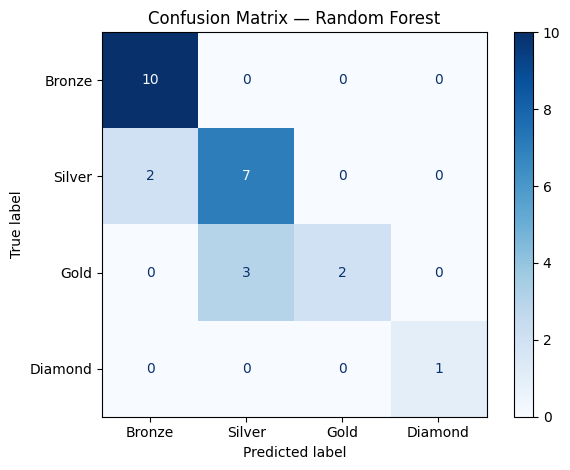

In [323]:
# CONFUSION MATRIX SKELETON
# Input: true labels and predicted labels
# Output: plotted confusion matrix
def plot_confusion_matrix(y_test, y_pred, labels):
    # TODO: build confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    # TODO: display it
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix — Random Forest")
    plt.tight_layout()
    plt.show()

    return None

# TODO: plot confusion matrix for the Random Forest predictions
labels = ["Bronze", "Silver", "Gold", "Diamond"]
plot_confusion_matrix(y_test, y_pred_rf, labels)

Baseline Accuracy: 0.53

               precision    recall  f1-score   support

      Bronze       0.65      0.65      0.65        40
     Diamond       0.80      0.80      0.80         5
        Gold       0.50      0.50      0.50        20
      Silver       0.37      0.37      0.37        35

    accuracy                           0.53       100
   macro avg       0.58      0.58      0.58       100
weighted avg       0.53      0.53      0.53       100



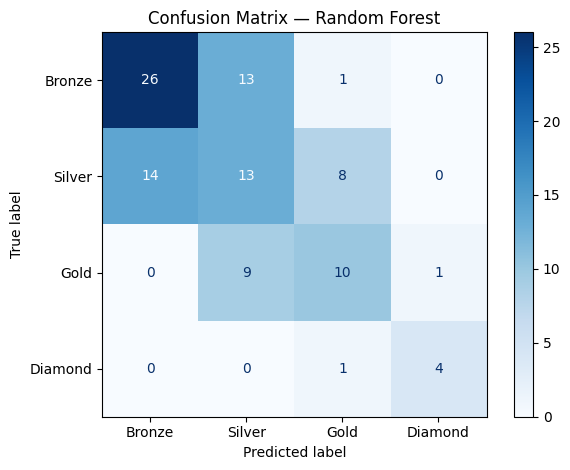

In [324]:
# Baseline accuracy — full comparison
baseline_acc = accuracy_score(df["TrueTier"], df["BaselineTier"])
print("Baseline Accuracy:", baseline_acc)

print("\n", classification_report(df["TrueTier"], df["BaselineTier"]))

labels = ["Bronze", "Silver", "Gold", "Diamond"]
plot_confusion_matrix(df["TrueTier"], df["BaselineTier"], labels)

## 11. Feature importance

For Random Forest, scikit-learn exposes built-in feature importance.

Interpretation questions:
- Which variables matter most?
- Are these the variables we expected?
- Do they align with the simulator design?


KDR                                    0.069276
WinRate                                0.061452
Captures                               0.050789
Losses                                 0.050345
Wins                                   0.050253
CapturesPerMatch                       0.043671
ObjectiveActions                       0.039946
ObjectiveImpact                        0.036400
ObjectiveActionsPerMatch               0.033486
Kills                                  0.031669
ReturnsPerMatch                        0.031268
KillsPerMatch                          0.030928
Returns                                0.029641
FlagGrabs                              0.028707
SupportImpact                          0.027938
KillsWhileCarrierAlive                 0.027152
GrabsPerMatch                          0.026184
DuelsWon                               0.025545
KillsWhileCarrierAlivePerMatch         0.024613
Draws                                  0.019846
InterceptionsPerMatch                  0

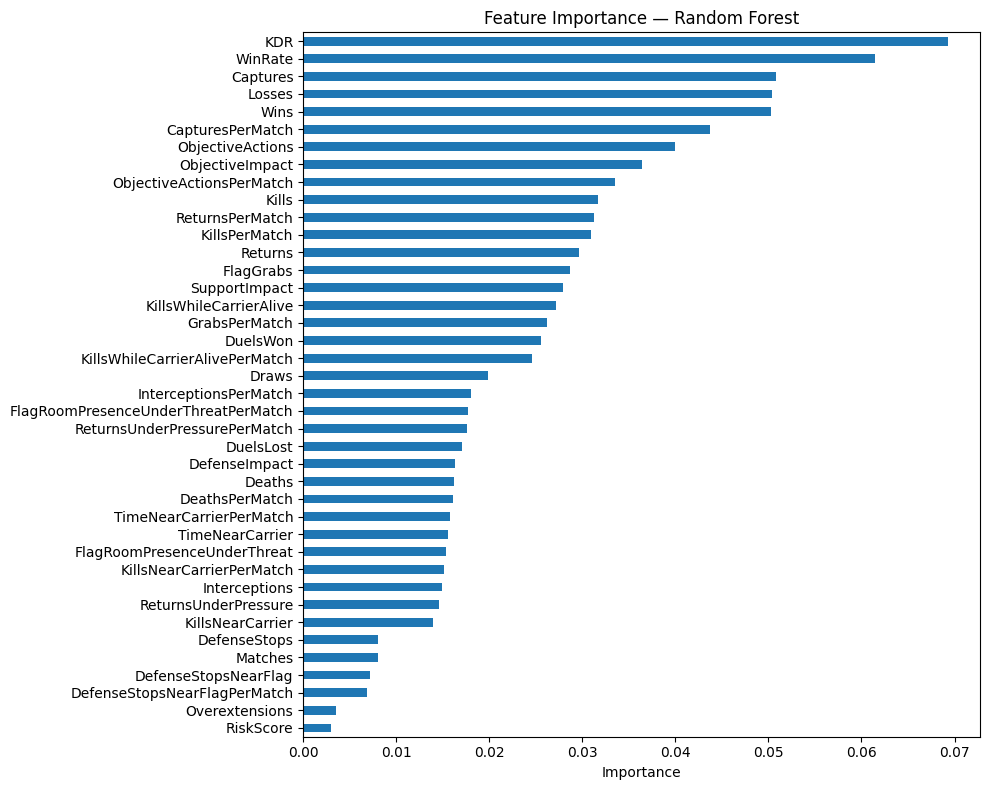

In [325]:
# FUNCTION SKELETON
# Input: trained Random Forest model + feature names
# Output: table and bar plot of feature importance
def plot_rf_feature_importance(model, feature_cols):
    # TODO: extract model.feature_importances_
    importances = model.feature_importances_

    # TODO: convert to pandas Series, sort, print
    importance_series = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    print(importance_series)

    # TODO: plot a horizontal bar chart
    importance_series.sort_values().plot(kind="barh", figsize=(10, 8))
    plt.title("Feature Importance — Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return None

# TODO: call the function
plot_rf_feature_importance(rf_model, feature_cols)

## 12. Optional extension — ablation study

Ablation removes one **group of features** at a time and retrains the model.

This helps us understand what the model depends on.


In [326]:
# OPTIONAL FEATURE GROUPS
feature_groups = {
    "combat": [
        "KDR", "KillsPerMatch", "DeathsPerMatch", "DuelsWon", "DuelsLost"
    ],
    "objective": [
        "CapturesPerMatch", "ReturnsPerMatch", "InterceptionsPerMatch", "ObjectiveActionsPerMatch"
    ],
    "support": [
        "TimeNearCarrierPerMatch", "KillsNearCarrierPerMatch", "KillsWhileCarrierAlivePerMatch"
    ],
    "defense": [
        "DefenseStopsNearFlagPerMatch", "FlagRoomPresenceUnderThreatPerMatch", "ReturnsUnderPressurePerMatch"
    ],
    "risk": [
        "RiskScore", "Overextensions"
    ],
}


In [328]:
# OPTIONAL FUNCTION SKELETON
# Input:
#   full feature set + grouped features
# Output:
#   accuracy drop when removing each feature group
def run_ablation_study(full_df, all_features, target_col, feature_groups):
    # TODO:
    # 1. train a full model and store its performance
    all_group_cols = [col for cols in feature_groups.values() for col in cols]
    grouped_features = [f for f in all_features if f in all_group_cols]

    X_full = full_df[grouped_features]
    y = full_df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.25, random_state=42, stratify=y)
    full_model = train_random_forest(X_train, y_train)
    full_acc = accuracy_score(y_test, full_model.predict(X_test))

    # 2. for each group:
    #       remove that group
    #       retrain model
    #       evaluate again
    results = [{"group_removed": "none (full model)", "accuracy": full_acc, "accuracy_drop": 0.0}]

    for group_name, group_cols in feature_groups.items():
        reduced_features = [f for f in grouped_features if f not in group_cols]
        X_reduced = full_df[reduced_features]
        X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.25, random_state=42, stratify=y)
        model_r = train_random_forest(X_train_r, y_train_r)
        acc_r = accuracy_score(y_test_r, model_r.predict(X_test_r))
        results.append({
            "group_removed": group_name,
            "accuracy": acc_r,
            "accuracy_drop": full_acc - acc_r,
        })

    # 3. compare scores
    results_df = pd.DataFrame(results).sort_values("accuracy_drop", ascending=False)
    print(results_df.to_string(index=False))

    return results_df

# TODO: call the ablation study if time allows
run_ablation_study(df, feature_cols, "TrueTier", feature_groups)

    group_removed  accuracy  accuracy_drop
          defense      0.72           0.04
        objective      0.72           0.04
             risk      0.76           0.00
none (full model)      0.76           0.00
           combat      0.80          -0.04
          support      0.80          -0.04


,group_removed,accuracy,accuracy_drop
4,defense,0.72,0.04
2,objective,0.72,0.04
5,risk,0.76,0.00
0,none (full model),0.76,0.00
1,combat,0.80,-0.04
3,support,0.80,-0.04


## 13. Reflection

Write short answers:

1. Did the ML model outperform the baseline?  
Yes. The rule-based baseline achieved 0.53 accuracy, while the Random Forest reached 0.80 and Logistic Regression 0.68. Both ML models clearly outperform the hand-crafted scoring approach.

2. Which metrics were most informative?  
F1 macro was the most informative, since the classes are imbalanced (only 1 Diamond, 10 Bronze, 5 Gold, 9 Silver in the test set). Accuracy alone is misleading in this context. The Gold class had recall of only 0.40 in the Random Forest despite high overall accuracy.

3. Was combat alone enough?  
No. The ablation study showed that removing combat slightly improved accuracy. This suggests combat metrics are either redundant with other features or noisy for tier prediction in this dataset.

4. Did role-aware features help?  
Yes, partially. Removing objective and defense features each caused a 0.04 accuracy drop, meaning they contributed meaningful signal. Support features showed no drop, suggesting they were redundant given the other features present.

5. What extra telemetry would you log if you redesigned the simulator?  
Time-to-capture (how efficiently a runner converts grabs into captures), positioning data relative to the flag, and decision timing under pressure (e.g. whether a player retreats or pushes when low health near the flag). These would better distinguish skilled play from high-volume but low-quality actions.

**Reminder:** good predictive modeling is not only about accuracy — it is also about interpretation.